In [7]:
import sys
sys.path.append('..')

import numpy as np
import torch
from tqdm import tqdm

%matplotlib inline
import matplotlib.pyplot as plt

In [8]:
def marginals(joint: torch.Tensor):
    # split joint samples into marginals X,Y
    dim = joint.shape[-1]
    mask = torch.zeros(dim, dtype=torch.bool, device=joint.device)
    mask[dim//2+1:] = True
    mask[1] = True
    return joint[:,~mask], joint[:,mask]


# exp config
device = torch.device('cuda:0')
hdgm_dim = 40
n_tests = 100
n_test_samples = 8000
n_subset_test_samples = 1000
pretrained_path = "exp/pretrained/deepkernel/hdgm40/mlp_small/best.pt"


In [9]:
from torch.utils.data import DataLoader
from data.toy import BlobHD
import metrics

# Define dataset / dataloader
# TODO: try using new dataset (direct sampling)
dataset = BlobHD(size=n_tests*n_test_samples, dim=hdgm_dim)
dataloader = DataLoader(dataset=dataset,
                        batch_size=n_test_samples,
                        shuffle=True)


In [10]:
from model.mlp import MLP
from kernel import Gaussian, DeepKernel
from utils import utils

# Define model
featurizer = MLP(features=[20, 60, 60, 60],
                 activation='ELU')
feature_kernel = Gaussian(trainable=True)
smoothing_kernel = Gaussian(trainable=True)
model = DeepKernel(featurizer, feature_kernel, smoothing_kernel, eps=0.01, trainable=True)
model = model.to(device)

# load model
utils.load_checkpoint(pretrained_path, model, optimizer=None, scheduler=None, device=device)
k = model.eval()
l = model.eval()


In [11]:
data_iter = iter(dataloader)
batch = next(data_iter).to(device)
X,Y = marginals(batch)

Kxx = k(X,X)
Lyy = l(Y,Y)
Kxx.shape
Lyy.shape


torch.Size([8000, 8000])

In [12]:
with torch.no_grad():
    hsic_n8000,_ = metrics.hsic.hsic_fast(Kxx, Lyy, compute_var=False)
    hsic_n1000,_ = metrics.hsic.hsic_fast(Kxx[:1000,:1000], Lyy[:1000,:1000], compute_var=False)
hsic_n8000 = hsic_n8000.item()
hsic_n1000 = hsic_n1000.item()
hsic_n8000, hsic_n1000


(1.5183917412286974e-06, -3.419683025640552e-06)

In [7]:
# compute hsic values for random subsets of size 1000 of 8000 total test samples
hsic_vals = []
for i in tqdm(range(1000)):
    idx = np.random.choice(8000,1000,replace=False)
    idx_mat = np.ix_(idx, idx)
    with torch.no_grad():
        hsic_est,_ = metrics.hsic.hsic_fast(Kxx[idx_mat], Lyy[idx_mat], compute_var=False)
    hsic_vals.append(hsic_est.item())


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:01<00:00, 713.64it/s]


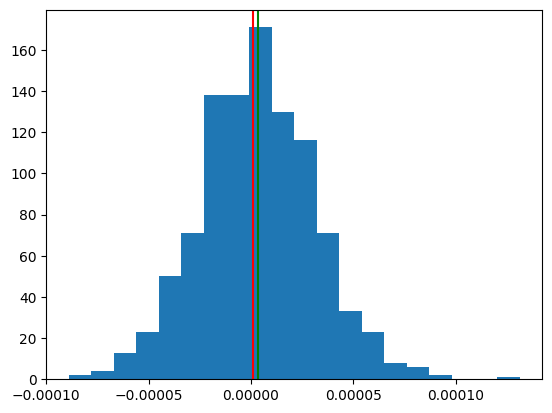

In [8]:
plt.hist(hsic_vals, bins=20)
plt.axvline(hsic_n8000, color='r')
plt.axvline(np.mean(hsic_vals), color='g')

In [13]:
with torch.no_grad():
    test_stats = metrics.hsic.permutation_test(k,l,X,Y)

    subtest_sizes = [1000]*8
    chunk_idx = np.split(np.random.permutation(8000), np.cumsum(subtest_sizes))

    sub_test_stats = []
    for idx in tqdm(chunk_idx[:-1]):
        stats = metrics.hsic.permutation_test(k,l,X[idx],Y[idx])
        sub_test_stats.append(stats)



running permutation test... |          | 0/500 [00:00<?]

100%|██████████| 8/8 [00:02<00:00,  3.64it/s]                 


In [14]:
hsic_8000, var_8000, p_value_8000, thresh_8000 = test_stats
hsic_1000_arr, var_1000_arr, p_value_1000_arr, thresh_1000_arr = zip(*sub_test_stats)

hsic_8000 = hsic_8000.item()
hsic_1000_arr = [h.item() for h in hsic_1000_arr]

hsic_count = p_value_count = 0
for hsic_n1000, p_value_n1000 in zip(hsic_1000_arr, p_value_1000_arr):
    if hsic_n1000 > hsic_n8000:
        hsic_count += 1
    if p_value_n1000 < p_value_8000:
        p_value_count += 1

print('hsic_8000:', hsic_n8000)
print('hsic_1000:', hsic_1000_arr)
print('#{hsic_1000 > hsic_8000}:', hsic_count)
print()
print('p-value_8000:', p_value_8000)
print('p-value_1000:', p_value_1000_arr)
print('#{p-value_1000 < p-value_8000}:', p_value_count)




hsic_8000: 1.5183917412286974e-06
hsic_1000: [-7.799521881679539e-06, -1.395372692059027e-05, 1.0801692951645236e-05, 1.5535253623966128e-05, 2.729685729718767e-05, 6.860302619315917e-06, -7.662391908525024e-06, 1.9695684386533685e-05]
#{hsic_1000 > hsic_8000}: 5

p-value_8000: 0.336
p-value_1000: (0.608, 0.65, 0.332, 0.252, 0.132, 0.4, 0.596, 0.18)
#{p-value_1000 < p-value_8000}: 4


In [15]:
with torch.no_grad():
    
    n_reject = 0
    n_reject_subtest = np.zeros(8)

    for batch in tqdm(dataloader):
        joint = batch.to(device)
        X,Y = marginals(joint)
        hsic_8000, _, p_value_8000, _ = metrics.hsic.permutation_test(k,l,X,Y)
        if p_value_8000 < 0.05:
            n_reject += 1

        subtest_sizes = [1000]*8
        chunk_idx = np.split(np.random.permutation(8000), np.cumsum(subtest_sizes))

        for i,idx in enumerate(chunk_idx[:-1]):
            hsic_1000, _, p_value_1000, _ = metrics.hsic.permutation_test(k,l,X[idx],Y[idx])
            if p_value_1000 < 0.05:
                n_reject_subtest[i] += 1


100%|██████████| 100/100 [33:16<00:00, 19.97s/it]


In [16]:
power = n_reject/n_tests
power_subtests = n_reject_subtest/n_tests
print('power_8000:', power)
print('power_1000:', power_subtests)

power_8000: 0.06
power_1000: [0.08 0.07 0.07 0.05 0.06 0.1  0.05 0.05]
